# HDFS 简历与岗位语料：技能词和停用词分析

**目标**

1. 从 HDFS 原始简历与岗位 CSV 建立可复现的数据快照。
2. 以显式技能字段为主证据，统计技能频率、覆盖率、共现关系和写法变体。
3. 以文本 `TF`、`DF`、跨语料分布为证据，生成停用词候选。
4. 输出候选 JSON/CSV；**不直接覆盖**生产用 `stopwords.json` 和 `skill_alias.json`。

**成功标准**：Notebook 可在项目 VM 从头运行，输出数据质量报告、候选词表、图表和机器可读产物。

## 方法与边界

- **技能词**：优先相信 `skills`、`skills_required`、`skills_preferred`，因为这些字段有明确语义。
- **文本词频**：用于发现招聘套话、领域高频词和遗漏候选，不把“高频词”直接等同于技能。
- **停用词**：候选需高文档频率、低区分度，并排除显式技能词。
- **别名**：自动合并大小写、空白和现有映射能证明的变体；模糊相似项只进入人工复核表。
- 当前数据由有限岗位方向和技能池生成，因此结论只代表当前 HDFS 样本。

In [1]:
from __future__ import annotations

import json
import math
import re
import shutil
import subprocess
import tempfile
from collections import Counter
from datetime import datetime, timezone
from itertools import combinations
from pathlib import Path

import jieba
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "streaming").exists() else cwd.parent
STREAMING_DIR = PROJECT_ROOT / "streaming"
OUTPUT_DIR = STREAMING_DIR / "analysis_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HDFS_ROOT = "/resume_matching/raw"
MIN_SKILL_COUNT = 2
MIN_STOPWORD_DF_RATIO = 0.08
MIN_STOPWORD_TF = 10

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: /Users/yem/Developer/university/projects/resume-matching
OUTPUT_DIR: /Users/yem/Developer/university/projects/resume-matching/streaming/analysis_output


## 1. 从 HDFS 建立本次分析快照

In [2]:
def run(command: list[str]) -> subprocess.CompletedProcess:
    return subprocess.run(command, check=True, text=True, capture_output=True)


def hdfs_snapshot(kind: str, target_root: Path) -> list[Path]:
    target = target_root / kind
    target.mkdir(parents=True, exist_ok=True)
    run(["hdfs", "dfs", "-get", f"{HDFS_ROOT}/{kind}/*.csv", str(target)])
    return sorted(target.glob("*.csv"))


def read_csv_files(files: list[Path]) -> tuple[pd.DataFrame, pd.DataFrame]:
    frames = []
    errors = []
    for file in files:
        try:
            frame = pd.read_csv(file, dtype=str, keep_default_na=True)
            frame["_source_file"] = file.name
            frames.append(frame)
        except Exception as exc:
            errors.append({"file": file.name, "error": str(exc)})
    if not frames:
        raise RuntimeError("没有成功读取任何 CSV 文件")
    return pd.concat(frames, ignore_index=True), pd.DataFrame(errors)


snapshot_dir = Path(tempfile.mkdtemp(prefix="resume_matching_analysis_"))
resume_files = hdfs_snapshot("resumes", snapshot_dir)
job_files = hdfs_snapshot("jobs", snapshot_dir)
resumes, resume_read_errors = read_csv_files(resume_files)
jobs, job_read_errors = read_csv_files(job_files)

snapshot_meta = {
    "analyzed_at_utc": datetime.now(timezone.utc).isoformat(),
    "resume_files": len(resume_files),
    "job_files": len(job_files),
    "resume_rows": len(resumes),
    "job_rows": len(jobs),
}
snapshot_meta

{'analyzed_at_utc': '2026-06-11T22:25:28.165806+00:00',
 'resume_files': 50,
 'job_files': 49,
 'resume_rows': 328,
 'job_rows': 56}

## 2. 数据质量：缺失、重复、字段结构与可用性

In [3]:
def quality_table(df: pd.DataFrame, id_col: str, dataset: str) -> pd.DataFrame:
    rows = []
    for column in [c for c in df.columns if c != "_source_file"]:
        text = df[column].fillna("").astype(str).str.strip()
        rows.append({
            "dataset": dataset,
            "column": column,
            "rows": len(df),
            "missing_count": int((text == "").sum()),
            "missing_ratio": round(float((text == "").mean()), 4),
            "distinct_nonempty": int(text[text != ""].nunique()),
        })
    result = pd.DataFrame(rows)
    result["duplicate_id_rows"] = 0
    ids = df[id_col].fillna("").astype(str).str.strip()
    duplicate_rows = int(ids[ids != ""].duplicated(keep=False).sum())
    result.loc[result["column"] == id_col, "duplicate_id_rows"] = duplicate_rows
    return result


quality = pd.concat([
    quality_table(resumes, "resume_id", "resumes"),
    quality_table(jobs, "job_id", "jobs"),
], ignore_index=True)
quality.to_csv(OUTPUT_DIR / "data_quality.csv", index=False, encoding="utf-8-sig")

summary_quality = pd.DataFrame([
    {
        "dataset": "resumes",
        "files": len(resume_files),
        "rows": len(resumes),
        "empty_id_rows": int(resumes["resume_id"].fillna("").str.strip().eq("").sum()),
        "duplicate_nonempty_id_rows": int(resumes.loc[resumes["resume_id"].fillna("").str.strip().ne(""), "resume_id"].duplicated(keep=False).sum()),
        "read_errors": len(resume_read_errors),
    },
    {
        "dataset": "jobs",
        "files": len(job_files),
        "rows": len(jobs),
        "empty_id_rows": int(jobs["job_id"].fillna("").str.strip().eq("").sum()),
        "duplicate_nonempty_id_rows": int(jobs.loc[jobs["job_id"].fillna("").str.strip().ne(""), "job_id"].duplicated(keep=False).sum()),
        "read_errors": len(job_read_errors),
    },
])
display(summary_quality)
display(quality.sort_values(["dataset", "missing_ratio"], ascending=[True, False]).groupby("dataset").head(6))

,dataset,files,rows,empty_id_rows,duplicate_nonempty_id_rows,read_errors
0,resumes,50,328,55,10,0
1,jobs,49,56,20,9,0


,dataset,column,rows,missing_count,missing_ratio,distinct_nonempty,duplicate_id_rows
14,jobs,job_id,56,20,0.3571,28,9
21,jobs,skills_preferred,56,1,0.0179,51,0
15,jobs,job_title,56,0,0.0000,29,0
16,jobs,department,56,0,0.0000,25,0
17,jobs,location,56,0,0.0000,49,0
18,jobs,education_required,56,0,0.0000,9,0
9,resumes,certifications,328,207,0.6311,66,0
0,resumes,resume_id,328,55,0.1677,264,10
2,resumes,gender,328,4,0.0122,2,0
1,resumes,name,328,0,0.0000,199,0


## 3. 显式技能字段：频率、来源覆盖与写法变体

In [4]:
with open(STREAMING_DIR / "skill_alias.json", encoding="utf-8") as file:
    current_alias = {str(k).strip().lower(): str(v).strip() for k, v in json.load(file).items()}
with open(STREAMING_DIR / "stopwords.json", encoding="utf-8") as file:
    current_stopwords = set(json.load(file))


def clean_item(value: object) -> str:
    text = re.sub(r"<[^>]+>", " ", "" if pd.isna(value) else str(value))
    return re.sub(r"\s+", " ", text).strip(" ,，、|;；")


def split_items(value: object) -> list[str]:
    text = clean_item(value)
    return [item for part in re.split(r"[,，、|;；/]", text) if (item := clean_item(part))]


def canonicalize(item: str) -> str:
    cleaned = clean_item(item)
    return current_alias.get(cleaned.lower(), cleaned)


skill_sources = [
    ("resume", resumes, "skills"),
    ("job_required", jobs, "skills_required"),
    ("job_preferred", jobs, "skills_preferred"),
]
skill_rows = []
for source, frame, column in skill_sources:
    for row_index, value in frame[column].items():
        for raw_skill in split_items(value):
            skill_rows.append({
                "source": source,
                "row_index": int(row_index),
                "raw_skill": raw_skill,
                "normalized_key": re.sub(r"\s+", " ", raw_skill).strip().lower(),
                "canonical_skill": canonicalize(raw_skill),
            })

skill_mentions = pd.DataFrame(skill_rows)
skill_frequency = (
    skill_mentions.groupby("canonical_skill")
    .agg(
        mentions=("canonical_skill", "size"),
        resume_mentions=("source", lambda s: int((s == "resume").sum())),
        required_mentions=("source", lambda s: int((s == "job_required").sum())),
        preferred_mentions=("source", lambda s: int((s == "job_preferred").sum())),
        raw_variants=("raw_skill", lambda s: " | ".join(sorted(set(s), key=str.lower))),
        variant_count=("raw_skill", "nunique"),
    )
    .reset_index()
    .sort_values(["mentions", "canonical_skill"], ascending=[False, True])
)
skill_frequency["source_coverage"] = (
    (skill_frequency["resume_mentions"] > 0).astype(int)
    + (skill_frequency["required_mentions"] > 0).astype(int)
    + (skill_frequency["preferred_mentions"] > 0).astype(int)
)
skill_frequency.to_csv(OUTPUT_DIR / "skill_frequency.csv", index=False, encoding="utf-8-sig")

print("显式技能提及数:", len(skill_mentions))
print("标准化后技能数:", skill_frequency["canonical_skill"].nunique())
display(skill_frequency.head(30))

显式技能提及数: 2628
标准化后技能数: 35


,canonical_skill,mentions,resume_mentions,required_mentions,preferred_mentions,raw_variants,variant_count,source_coverage
23,Python,400,353,45,2,Py | py | python | Python | PYTHON,5,3
25,SQL,371,316,54,1,sql | SQL,2,3
15,Linux,203,165,33,5,Linux,1,3
21,Pandas,171,151,14,6,pandas | Pandas | PANDAS,3,3
3,Docker,152,110,13,29,docker | Docker,2,3
26,Spark,151,104,19,28,Apache Spark | pyspark | spark | Spark,4,3
29,Tableau,136,121,6,9,tableau | Tableau,2,3
19,MySQL,121,99,22,0,MySQL | mysql,2,2
0,Data Analysis,113,101,10,2,Data Analysis | 数据分析 | 数据统计,3,3
6,Excel,85,79,5,1,Excel,1,3


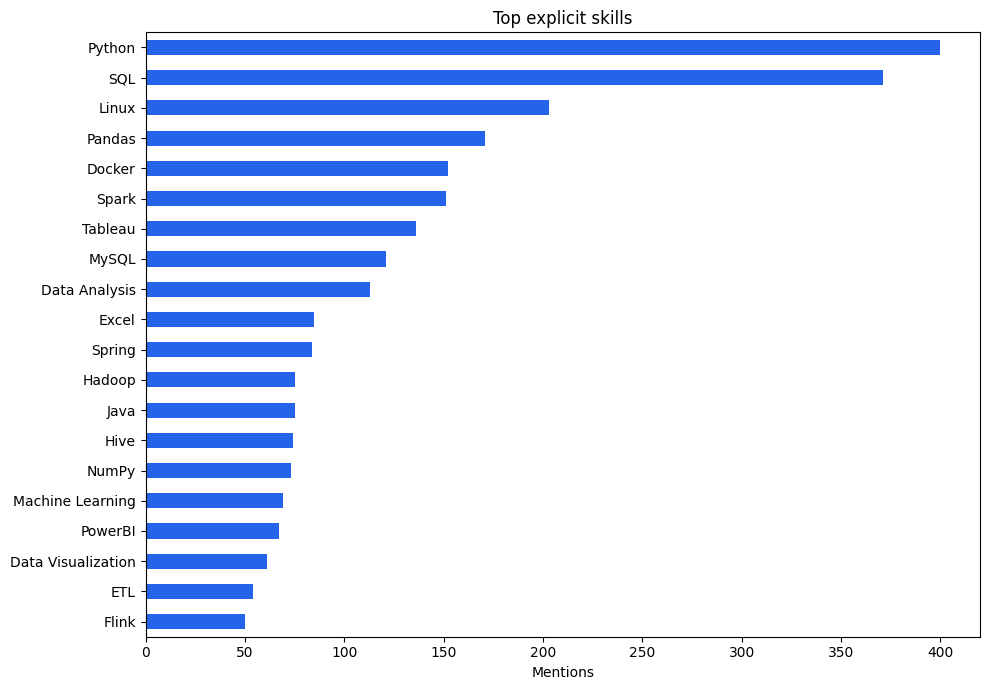

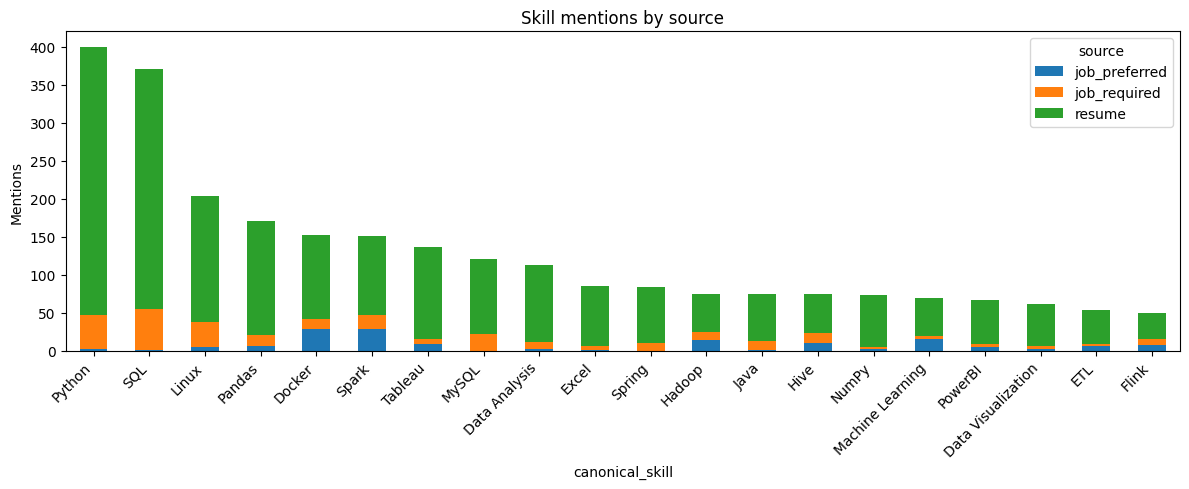

In [5]:
top = skill_frequency.head(20).sort_values("mentions")
ax = top.plot.barh(x="canonical_skill", y="mentions", figsize=(10, 7), legend=False, color="#2563eb")
ax.set(title="Top explicit skills", xlabel="Mentions", ylabel="")
plt.tight_layout()
plt.show()

source_counts = (
    skill_mentions.groupby(["canonical_skill", "source"]).size()
    .unstack(fill_value=0)
    .reindex(skill_frequency.head(20)["canonical_skill"])
)
source_counts.plot(kind="bar", stacked=True, figsize=(12, 5), title="Skill mentions by source")
plt.ylabel("Mentions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4. 技能共现：当前数据中的技术组合

In [6]:
pair_counter = Counter()
for source, frame, column in skill_sources:
    for value in frame[column]:
        skills = sorted(set(canonicalize(item) for item in split_items(value)))
        for left, right in combinations(skills, 2):
            pair_counter[(left, right)] += 1

skill_cooccurrence = pd.DataFrame([
    {"skill_a": pair[0], "skill_b": pair[1], "cooccurrence": count}
    for pair, count in pair_counter.most_common()
])
skill_cooccurrence.to_csv(OUTPUT_DIR / "skill_cooccurrence.csv", index=False, encoding="utf-8-sig")
display(skill_cooccurrence.head(30))

,skill_a,skill_b,cooccurrence
0,Python,SQL,305
1,Linux,SQL,185
2,Pandas,Python,165
3,Pandas,SQL,165
4,Python,Tableau,127
5,SQL,Tableau,127
6,Linux,Python,126
7,Docker,Linux,119
8,Linux,MySQL,119
9,Docker,SQL,110


## 5. 文本语料与分词：TF、DF、跨语料分布

In [7]:
RESUME_TEXT_COLUMNS = ["skills", "work_history", "major", "school", "certifications"]
JOB_TEXT_COLUMNS = [
    "job_title", "department", "skills_required", "skills_preferred",
    "job_description", "responsibilities", "requirements",
]


def combine_text(frame: pd.DataFrame, columns: list[str]) -> pd.Series:
    return frame[columns].fillna("").astype(str).agg(" ".join, axis=1).map(clean_item)


resume_documents = combine_text(resumes, RESUME_TEXT_COLUMNS).tolist()
job_documents = combine_text(jobs, JOB_TEXT_COLUMNS).tolist()

alias_pairs = sorted(current_alias.items(), key=lambda item: len(item[0]), reverse=True)
ALIAS_PATTERN = re.compile("|".join(re.escape(alias) for alias, _ in alias_pairs), flags=re.IGNORECASE)
TOKEN_PATTERN = re.compile(r"^[\u4e00-\u9fffA-Za-z][\u4e00-\u9fffA-Za-z0-9+#.\-]*$")


def normalize_aliases(text: str) -> str:
    # 单次最长匹配，避免 py -> Python 后再次命中 python，产生 Pythonthon。
    return ALIAS_PATTERN.sub(lambda match: current_alias[match.group(0).lower()], text)


def tokenize(text: str) -> list[str]:
    normalized = normalize_aliases(clean_item(text))
    tokens = []
    for token in jieba.lcut(normalized):
        token = token.strip()
        if len(token) > 40 or not TOKEN_PATTERN.match(token):
            continue
        tokens.append(current_alias.get(token.lower(), token))
    return tokens


corpora = {"resume": resume_documents, "job": job_documents}
token_rows = []
tokenized_documents = {}
for corpus, documents in corpora.items():
    tokenized_documents[corpus] = [tokenize(document) for document in documents]
    tf = Counter(token for tokens in tokenized_documents[corpus] for token in tokens)
    df = Counter(token for tokens in tokenized_documents[corpus] for token in set(tokens))
    for token, count in tf.items():
        token_rows.append({
            "corpus": corpus,
            "token": token,
            "tf": count,
            "df": df[token],
            "df_ratio": df[token] / max(len(documents), 1),
        })

token_stats_long = pd.DataFrame(token_rows)
token_stats = (
    token_stats_long.pivot_table(index="token", columns="corpus", values=["tf", "df", "df_ratio"], fill_value=0)
)
token_stats.columns = [f"{metric}_{corpus}" for metric, corpus in token_stats.columns]
token_stats = token_stats.reset_index()
for column in ["tf_resume", "tf_job", "df_resume", "df_job", "df_ratio_resume", "df_ratio_job"]:
    if column not in token_stats:
        token_stats[column] = 0
token_stats["tf_total"] = token_stats["tf_resume"] + token_stats["tf_job"]
token_stats["df_total"] = token_stats["df_resume"] + token_stats["df_job"]
token_stats["df_ratio_total"] = token_stats["df_total"] / max(len(resumes) + len(jobs), 1)
token_stats["idf"] = np.log((1 + len(resumes) + len(jobs)) / (1 + token_stats["df_total"])) + 1
token_stats = token_stats.sort_values(["tf_total", "token"], ascending=[False, True])
token_stats.to_csv(OUTPUT_DIR / "token_frequency.csv", index=False, encoding="utf-8-sig")
display(token_stats.head(40))

Building prefix dict from the default dictionary ...


Loading model from cache /tmp/jieba.cache


Loading model cost 0.780 seconds.


Prefix dict has been built successfully.


,token,df_job,df_resume,df_ratio_job,df_ratio_resume,tf_job,tf_resume,tf_total,df_total,df_ratio_total,idf
45,Python,46.0,267.0,0.821429,0.814024,117.0,439.0,556.0,313.0,0.815104,1.203850
600,负责,56.0,303.0,1.000000,0.923780,122.0,324.0,446.0,359.0,0.934896,1.067139
49,SQL,55.0,317.0,0.982143,0.966463,90.0,331.0,421.0,372.0,0.968750,1.031665
337,开发,42.0,213.0,0.750000,0.649390,128.0,269.0,397.0,255.0,0.664062,1.408066
15,Data,18.0,150.0,0.321429,0.457317,71.0,314.0,385.0,168.0,0.437500,1.823345
383,数据,30.0,156.0,0.535714,0.475610,116.0,267.0,383.0,186.0,0.484375,1.722135
83,与,52.0,193.0,0.928571,0.588415,100.0,218.0,318.0,245.0,0.638021,1.447912
4,Analysis,13.0,111.0,0.232143,0.338415,43.0,220.0,263.0,124.0,0.322917,2.124930
517,科技,0.0,231.0,0.000000,0.704268,0.0,237.0,237.0,231.0,0.601562,1.506506
166,公司,34.0,180.0,0.607143,0.548780,36.0,197.0,233.0,214.0,0.557292,1.582605


## 6. 停用词候选：高 DF + 低区分度 + 技能保护

In [8]:
explicit_skills = set(skill_frequency["canonical_skill"])
protected_tokens = set(current_alias) | set(current_alias.values())
for skill in explicit_skills | set(current_alias.values()):
    protected_tokens.update({skill, skill.lower()})
    protected_tokens.update(part for part in re.findall(r"[\u4e00-\u9fff]+|[A-Za-z][A-Za-z0-9+#.\-]*", skill))
    protected_tokens.update(part.lower() for part in list(protected_tokens))

# 标点已在 tokenize 中移除；这里排除技能、当前停用词、纯英文单字符和明显实体编号。
candidate_stopwords = token_stats.copy()
candidate_stopwords["is_explicit_skill"] = candidate_stopwords["token"].map(
    lambda token: token in protected_tokens or token.lower() in protected_tokens
)
candidate_stopwords["already_stopword"] = candidate_stopwords["token"].isin(current_stopwords)
candidate_stopwords["max_corpus_df_ratio"] = candidate_stopwords[["df_ratio_resume", "df_ratio_job"]].max(axis=1)
candidate_stopwords["corpus_balance"] = (
    candidate_stopwords[["df_ratio_resume", "df_ratio_job"]].min(axis=1)
    / candidate_stopwords[["df_ratio_resume", "df_ratio_job"]].max(axis=1).replace(0, np.nan)
).fillna(0)
candidate_stopwords["stopword_score"] = (
    candidate_stopwords["max_corpus_df_ratio"]
    * np.log1p(candidate_stopwords["tf_total"])
    * (0.7 + 0.3 * candidate_stopwords["corpus_balance"])
)
candidate_stopwords["reason"] = np.where(
    candidate_stopwords["corpus_balance"] >= 0.2,
    "高文档频率且跨简历/岗位均常见",
    "在单侧语料中高文档频率，可能是模板套话",
)

candidate_stopwords = candidate_stopwords[
    (candidate_stopwords["max_corpus_df_ratio"] >= MIN_STOPWORD_DF_RATIO)
    & (candidate_stopwords["tf_total"] >= MIN_STOPWORD_TF)
    & (~candidate_stopwords["is_explicit_skill"])
    & candidate_stopwords["token"].str.len().between(1, 20)
].sort_values("stopword_score", ascending=False)

candidate_stopwords.to_csv(OUTPUT_DIR / "stopword_candidates.csv", index=False, encoding="utf-8-sig")
display(candidate_stopwords[[
    "token", "tf_total", "df_ratio_resume", "df_ratio_job", "stopword_score",
    "already_stopword", "reason",
]].head(60))

,token,tf_total,df_ratio_resume,df_ratio_job,stopword_score,already_stopword,reason
600,负责,446.0,0.923780,1.000000,5.963018,False,高文档频率且跨简历/岗位均常见
83,与,318.0,0.588415,0.928571,4.765071,True,高文档频率且跨简历/岗位均常见
337,开发,397.0,0.649390,0.750000,4.309150,False,高文档频率且跨简历/岗位均常见
499,的,199.0,0.097561,0.910714,3.532750,True,在单侧语料中高文档频率，可能是模板套话
427,核心,132.0,0.222561,0.857143,3.260730,False,高文档频率且跨简历/岗位均常见
166,公司,233.0,0.548780,0.607143,3.216644,False,高文档频率且跨简历/岗位均常见
383,数据,383.0,0.475610,0.535714,3.080546,False,高文档频率且跨简历/岗位均常见
89,业务,147.0,0.219512,0.732143,2.890156,False,高文档频率且跨简历/岗位均常见
315,工程师,150.0,0.314024,0.660714,2.793156,False,高文档频率且跨简历/岗位均常见
517,科技,237.0,0.704268,0.000000,2.697763,False,在单侧语料中高文档频率，可能是模板套话


### 停用词建议的使用方式

- `already_stopword=False`：新增候选，需检查它是否会损害匹配语义。
- 岗位名称、专业方向、技术名词即使高频，也不应自动加入。
- 生产词表应基于候选表人工确认；后续数据增长后重新运行本 Notebook。

## 7. 别名候选与规范技能清单

In [9]:
variant_groups = (
    skill_mentions.groupby("canonical_skill")
    .agg(
        mentions=("canonical_skill", "size"),
        raw_variants=("raw_skill", lambda s: sorted(set(s), key=str.lower)),
        normalized_keys=("normalized_key", lambda s: sorted(set(s))),
    )
    .reset_index()
)

alias_rows = []
for row in variant_groups.itertuples(index=False):
    for variant in row.raw_variants:
        if variant != row.canonical_skill:
            alias_rows.append({
                "alias": variant,
                "canonical_skill": row.canonical_skill,
                "evidence_mentions": int((skill_mentions["raw_skill"] == variant).sum()),
                "basis": "显式技能字段 + 当前映射/大小写归一",
            })

alias_candidates = pd.DataFrame(alias_rows).sort_values(
    ["evidence_mentions", "alias"], ascending=[False, True]
) if alias_rows else pd.DataFrame(columns=["alias", "canonical_skill", "evidence_mentions", "basis"])
alias_candidates.to_csv(OUTPUT_DIR / "alias_candidates.csv", index=False, encoding="utf-8-sig")

canonical_inventory = skill_frequency[
    (skill_frequency["mentions"] >= MIN_SKILL_COUNT)
    | (skill_frequency["source_coverage"] >= 2)
].copy()
canonical_inventory.to_csv(OUTPUT_DIR / "canonical_skill_inventory.csv", index=False, encoding="utf-8-sig")

display(alias_candidates.head(50))
display(canonical_inventory.head(50))

,alias,canonical_skill,evidence_mentions,basis
17,py,Python,136,显式技能字段 + 当前映射/大小写归一
18,python,Python,90,显式技能字段 + 当前映射/大小写归一
13,pandas,Pandas,83,显式技能字段 + 当前映射/大小写归一
0,数据分析,Data Analysis,82,显式技能字段 + 当前映射/大小写归一
22,pyspark,Spark,53,显式技能字段 + 当前映射/大小写归一
21,Apache Spark,Spark,19,显式技能字段 + 当前映射/大小写归一
19,PYTHON,Python,19,显式技能字段 + 当前映射/大小写归一
12,numpy,NumPy,18,显式技能字段 + 当前映射/大小写归一
20,sql,SQL,17,显式技能字段 + 当前映射/大小写归一
2,数据可视化,Data Visualization,17,显式技能字段 + 当前映射/大小写归一


,canonical_skill,mentions,resume_mentions,required_mentions,preferred_mentions,raw_variants,variant_count,source_coverage
23,Python,400,353,45,2,Py | py | python | Python | PYTHON,5,3
25,SQL,371,316,54,1,sql | SQL,2,3
15,Linux,203,165,33,5,Linux,1,3
21,Pandas,171,151,14,6,pandas | Pandas | PANDAS,3,3
3,Docker,152,110,13,29,docker | Docker,2,3
26,Spark,151,104,19,28,Apache Spark | pyspark | spark | Spark,4,3
29,Tableau,136,121,6,9,tableau | Tableau,2,3
19,MySQL,121,99,22,0,MySQL | mysql,2,2
0,Data Analysis,113,101,10,2,Data Analysis | 数据分析 | 数据统计,3,3
6,Excel,85,79,5,1,Excel,1,3


## 8. 生成可审查产物（不覆盖现有配置）

In [10]:
# 自动推荐采用保守策略：统计候选还需命中“招聘功能词”白名单。
# 技术方向词（如 数据、开发、后端、系统）只保留在 CSV，绝不自动删除。
SAFE_STOPWORD_TERMS = {
    "负责", "要求", "熟悉", "掌握", "了解", "能够", "进行", "相关",
    "工作", "岗位", "具备", "参与", "使用", "以上", "以及", "协助",
    "完成", "良好", "优先", "拥有", "主要", "包括",
}
new_stopword_candidates = (
    candidate_stopwords.loc[
        (~candidate_stopwords["already_stopword"])
        & candidate_stopwords["token"].isin(SAFE_STOPWORD_TERMS),
        "token",
    ]
    .tolist()
)
recommended_stopwords = sorted(current_stopwords | set(new_stopword_candidates))

recommended_alias = dict(current_alias)
for row in alias_candidates.itertuples(index=False):
    recommended_alias.setdefault(row.alias.lower(), row.canonical_skill)

with open(OUTPUT_DIR / "recommended_stopwords.json", "w", encoding="utf-8") as file:
    json.dump(recommended_stopwords, file, ensure_ascii=False, indent=2)
with open(OUTPUT_DIR / "recommended_skill_alias.json", "w", encoding="utf-8") as file:
    json.dump(dict(sorted(recommended_alias.items())), file, ensure_ascii=False, indent=2)

analysis_summary = {
    **snapshot_meta,
    "explicit_skill_mentions": int(len(skill_mentions)),
    "canonical_skill_count": int(skill_frequency["canonical_skill"].nunique()),
    "canonical_inventory_count": int(len(canonical_inventory)),
    "stopword_candidate_count": int(len(candidate_stopwords)),
    "new_recommended_stopword_count": int(len(new_stopword_candidates)),
    "alias_candidate_count": int(len(alias_candidates)),
    "top_skills": skill_frequency.head(15)[["canonical_skill", "mentions"]].to_dict("records"),
    "top_new_stopwords": new_stopword_candidates[:30],
}
with open(OUTPUT_DIR / "analysis_summary.json", "w", encoding="utf-8") as file:
    json.dump(analysis_summary, file, ensure_ascii=False, indent=2)

print(json.dumps(analysis_summary, ensure_ascii=False, indent=2))
print("\n输出文件:")
for output in sorted(OUTPUT_DIR.iterdir()):
    print("-", output.name)

{
  "analyzed_at_utc": "2026-06-11T22:25:28.165806+00:00",
  "resume_files": 50,
  "job_files": 49,
  "resume_rows": 328,
  "job_rows": 56,
  "explicit_skill_mentions": 2628,
  "canonical_skill_count": 35,
  "canonical_inventory_count": 27,
  "stopword_candidate_count": 117,
  "new_recommended_stopword_count": 12,
  "alias_candidate_count": 27,
  "top_skills": [
    {
      "canonical_skill": "Python",
      "mentions": 400
    },
    {
      "canonical_skill": "SQL",
      "mentions": 371
    },
    {
      "canonical_skill": "Linux",
      "mentions": 203
    },
    {
      "canonical_skill": "Pandas",
      "mentions": 171
    },
    {
      "canonical_skill": "Docker",
      "mentions": 152
    },
    {
      "canonical_skill": "Spark",
      "mentions": 151
    },
    {
      "canonical_skill": "Tableau",
      "mentions": 136
    },
    {
      "canonical_skill": "MySQL",
      "mentions": 121
    },
    {
      "canonical_skill": "Data Analysis",
      "mentions": 113
    },
   

## 9. 结论解释与下一步

运行后重点审查：

1. `skill_frequency.csv`：决定规范技能清单。
2. `alias_candidates.csv`：确认别名是否确实同义。
3. `stopword_candidates.csv`：逐项确认是否属于模板套话，而不是匹配信号。
4. `recommended_*.json`：仅是候选产物；审核后再替换 `streaming/` 下现有配置并同步 HDFS。

推荐验证流程：

1. 使用旧词表和候选新词表分别处理同一批数据。
2. 比较 token 数量、空文本率、TF-IDF 词表规模和 Top-K 匹配结果。
3. 若匹配结果出现岗位方向信息丢失，移除对应停用词。
4. 数据规模或生成模板变化后重新运行本 Notebook。

In [11]:
shutil.rmtree(snapshot_dir, ignore_errors=True)
print("临时 HDFS 快照已清理；分析产物保留在", OUTPUT_DIR)

临时 HDFS 快照已清理；分析产物保留在 /media/psf/resume-matching/streaming/analysis_output
